# 1. projekt



Oldja meg

$$
y'-y=\sin(x)
$$

kde-t a Matlab/Octave `dsolve` függvénye segítségével. 

Ábrázolja az egyenlet vektormezejét a $[-3,3] \times [-3,10]$-en és rajzoltassa rá az $y(-3)=0.55,\ \  y(-3)=0.6,\ \  y(-3)=1$
kezdeti értékekhez tartozó megoldásokat is.


## dsolve megoldás

In [1]:
import sympy as sp
t = sp.symbols("t")
y = sp.symbols("y", cls=sp.Function)
the_eq = sp.Eq(y(t).diff(t), sp.sin(t) + y(t))
gen_sol = sp.dsolve(the_eq)
print(gen_sol.rhs)




C1*exp(t) - sin(t)/2 - cos(t)/2


## Vektormező + megoldások

explicit alakra hozva:
$$
y' = y + \sin(t) = f(t, y)
$$

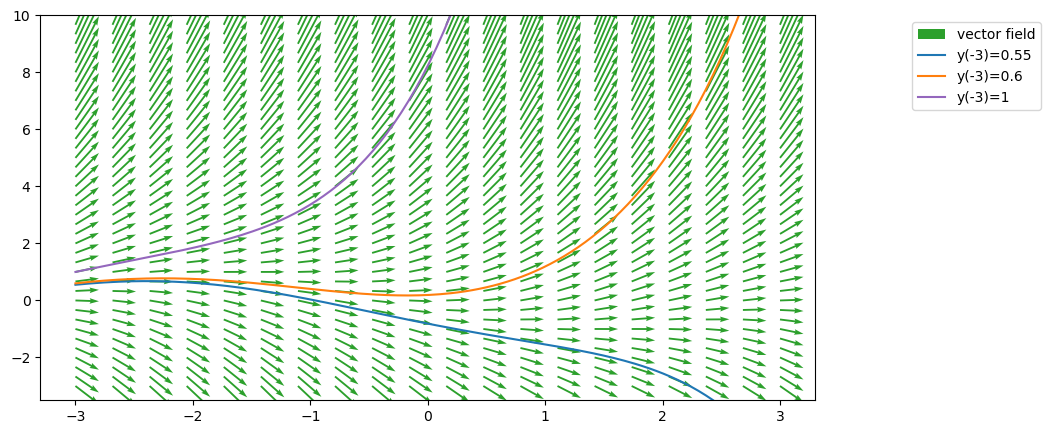

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"]=10,5


T, Y = np.meshgrid(np.linspace(-3,3,20), np.linspace(-3,10,40))
DT = np.ones(np.shape(T))
DY = np.sin(T) + Y
L = np.sqrt(DT*DT + DY*DY)
# DT = DT / L
# DY = DY / L

ax = plt.subplot()
#plt.quiver(T, Y, DT, DY, color="tab:green") # x=0.8, the orange vs. vectors

# https://stackoverflow.com/questions/48646094/how-to-get-unit-vectors-using-quiver-in-matplotlib
# the scale stuff found here (not how to get unit vecs...)
plt.quiver(T,Y, DT, DY, 
  units='xy', angles='xy', scale_units='xy', scale=5.0, 
  color="tab:green",           
)

y0 = [0.55, 0.6, 1]
part_sol1 = sp.lambdify(t, sp.dsolve(the_eq, ics={y(-3): y0[0]}).rhs)
part_sol2 = sp.lambdify(t, sp.dsolve(the_eq, ics={y(-3): y0[1]}).rhs)
part_sol3 = sp.lambdify(t, sp.dsolve(the_eq, ics={y(-3): y0[2]}).rhs)


xx = np.linspace(-3,3,200);
ax.plot(xx, part_sol1(xx), color="tab:blue")
ax.plot(xx, part_sol2(xx), color="tab:orange")
ax.plot(xx, part_sol3(xx), color="tab:purple")

# C1 = (0.6 + np.sin(-3)/2 + np.cos(-3)/2 )*np.exp(3)
# ps2 = lambda x: C1*np.exp(x)-np.sin(x)/2-np.cos(x)/2
# print(np.sum(np.abs(part_sol2(xx)-ps2(xx))))
# ax.plot(xx, ps2(xx), color="tab:orange")


plt.legend(
  ["vector field", "y(-3)=" + str(y0[0]), "y(-3)=" + str(y0[1]), "y(-3)=" + str(y0[2])],
  bbox_to_anchor=(1.3, 1.0)
)
#plt.axis("equal")
plt.ylim(-3.5, 10)
plt.show()
